# Phase 3 — Random Forest ML

**Target:** `on_off_ratio` 예측  
**Data:** `layer_sweep.csv` (73개 트랜지스터 측정값)  
**Model:** Random Forest (n_estimators=500)

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

ROOT = Path.cwd().parent
DATA = ROOT / "data" / "processed"

df_raw = pd.read_csv(DATA / "layer_sweep.csv")
print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
df_raw.head(3)


Loaded: 73 rows x 9 cols


,date,layers,filename,id_on_A,id_off_A,on_off_ratio,vgs_min_V,vgs_max_V,n_points
0,16-08,10,AB-AA2-T14-Fast-1-vgs_sweep-vgs_sweep,0.000026,0.000004,7.0,-10.0,10.0,2500
1,16-08,10,AB-AA3-T14-Fast-1-vgs_sweep-vgs_sweep,0.000029,0.000004,8.0,-10.0,10.0,2500
2,16-08,10,AB-AA4-T14-Fast-1-vgs_sweep-vgs_sweep,0.000018,0.000004,5.0,-10.0,10.0,2500


## Section 1 — Feature Matrix 구성

`i_on`은 Spurious Correlation으로 제외 — `on_off_ratio = i_on ÷ i_off`이고 `i_off`가 noise floor에 고정되어 있어 `i_on`이 target과 수학적으로 거의 동일함.

In [2]:
FEATURES = ["layers", "vgs_min_V", "vgs_max_V", "n_points"]
TARGET   = "on_off_ratio"

df = df_raw[FEATURES + [TARGET]].dropna().reset_index(drop=True)

X = df[FEATURES]
y = df[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Target range         : {y.min():.2f} — {y.max():.2f}")
print(f"Target mean ± std    : {y.mean():.2f} ± {y.std():.2f}")
print()
print("Features used:")
for f in FEATURES:
    print(f"  {f:15s}  range [{X[f].min():.1f}, {X[f].max():.1f}]")

# Quick feature summary table
X.describe().round(2)


Feature matrix shape : (73, 4)
Target shape         : (73,)
Target range         : 2.50 — 17.00
Target mean ± std    : 6.79 ± 2.12

Features used:
  layers           range [10.0, 60.0]
  vgs_min_V        range [-15.0, 0.0]
  vgs_max_V        range [4.5, 15.0]
  n_points         range [500.0, 3011.0]


,layers,vgs_min_V,vgs_max_V,n_points
count,73.00,73.00,73.00,73.00
mean,35.21,-9.86,10.06,2482.67
std,17.09,1.86,1.06,251.55
min,10.00,-15.00,4.46,500.00
25%,20.00,-10.00,10.00,2500.00
50%,40.00,-10.00,10.00,2500.00
75%,50.00,-10.00,10.00,2500.00
max,60.00,0.00,15.00,3011.00


## Section 2 — Train/Test Split

전체 73개 실험 데이터를 80/20으로 분리. `random_state=42`로 재현성 보장.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print()

# Layer distribution in each split
print("Layer distribution — train:")
print(X_train["layers"].value_counts().sort_index().to_dict())
print("Layer distribution — test:")
print(X_test["layers"].value_counts().sort_index().to_dict())


Train : 58 samples (79%)
Test  : 15  samples (21%)

Layer distribution — train:
{10: 7, 20: 10, 30: 8, 40: 13, 50: 11, 60: 9}
Layer distribution — test:
{10: 5, 20: 2, 30: 3, 40: 1, 50: 1, 60: 3}


## Section 3 — Random Forest 학습

500개 Decision Tree의 평균으로 예측. Train RMSE vs Test RMSE 차이로 overfitting 여부 판단.

                         Train      Test
----------------------------------------
RMSE                    2.1156    1.0630
R²                      0.1522   -0.0865



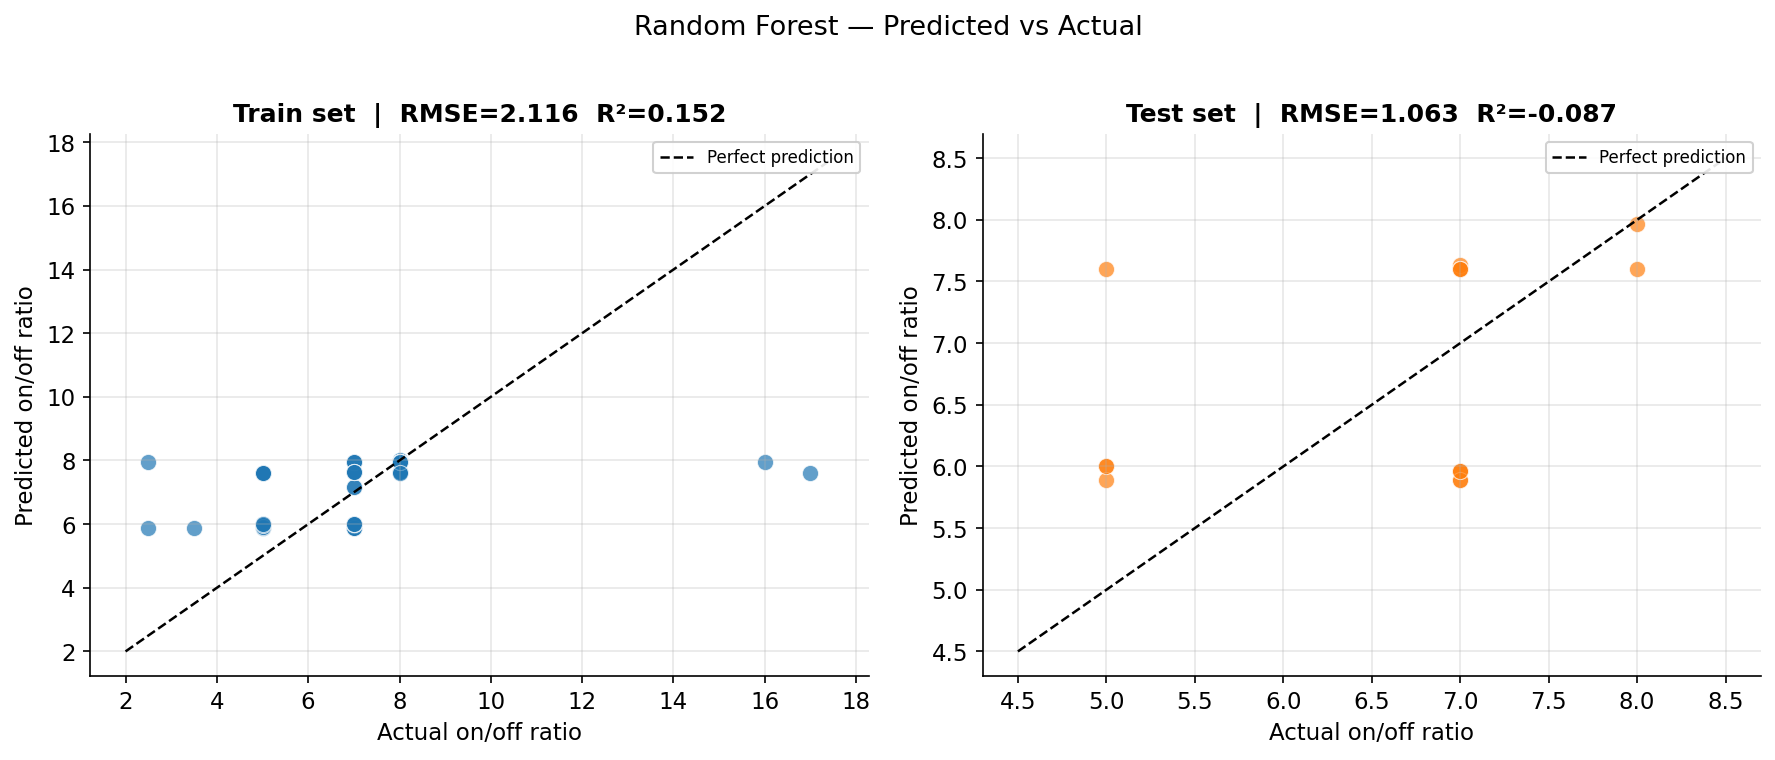

In [4]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test  = root_mean_squared_error(y_test,  y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print("=" * 40)
print(f"{'':20s}  {'Train':>8}  {'Test':>8}")
print("-" * 40)
print(f"{'RMSE':20s}  {rmse_train:8.4f}  {rmse_test:8.4f}")
print(f"{'R²':20s}  {r2_train:8.4f}  {r2_test:8.4f}")
print("=" * 40)
print()

# Scatter: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, split, color in [
    (axes[0], y_train, y_pred_train, "Train", "#1f77b4"),
    (axes[1], y_test,  y_pred_test,  "Test",  "#ff7f0e"),
]:
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, color=color, alpha=0.7, edgecolors="white",
               linewidths=0.5, s=60)
    lo = min(y_true.min(), y_pred.min()) - 0.5
    hi = max(y_true.max(), y_pred.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect prediction")
    ax.set_xlabel("Actual on/off ratio", fontsize=11)
    ax.set_ylabel("Predicted on/off ratio", fontsize=11)
    ax.set_title(f"{split} set  |  RMSE={rmse:.3f}  R²={r2:.3f}",
                 fontsize=12, fontweight="bold")
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.3)

fig.suptitle("Random Forest — Predicted vs Actual", fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_rf_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 4 — Feature Importance 시각화

각 feature가 on/off ratio 예측에 기여하는 비중. 값이 클수록 해당 feature가 splitting 결정에 더 많이 사용됨.

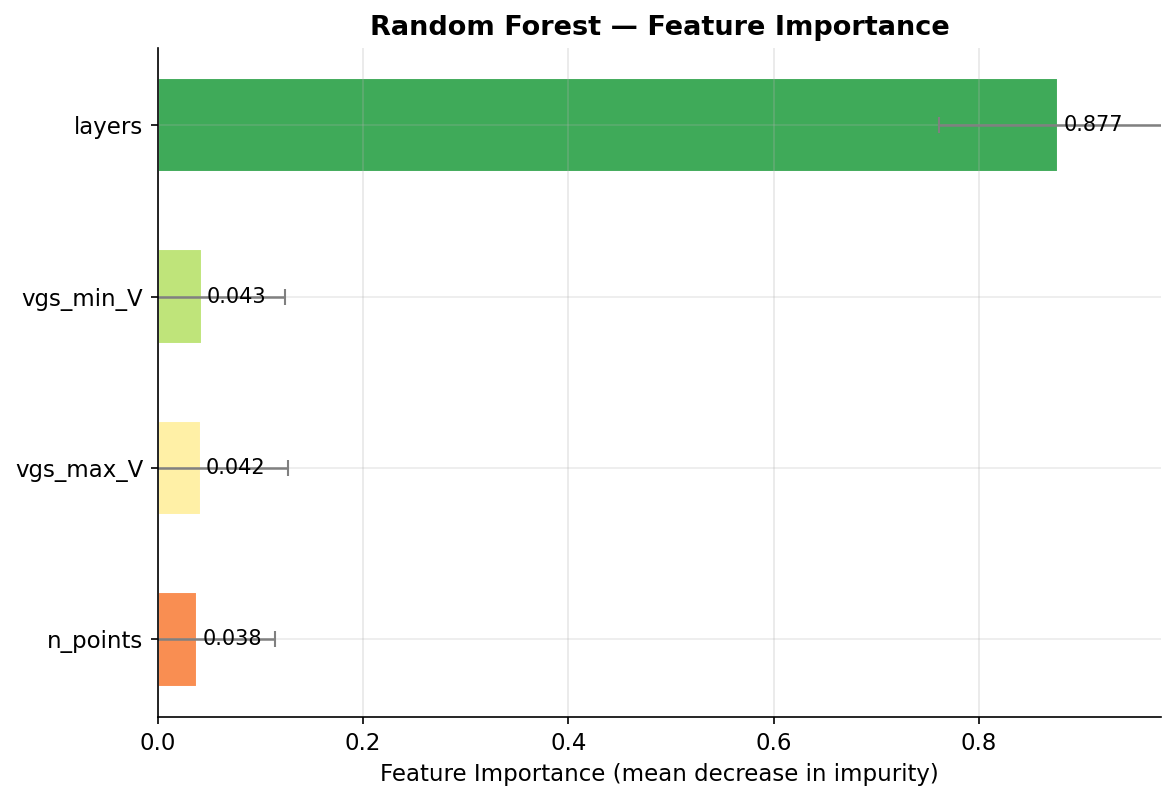

Feature Importance (sorted):
  layers           0.8773 ± 0.1165
  vgs_min_V        0.0426 ± 0.0812
  vgs_max_V        0.0419 ± 0.0854
  n_points         0.0382 ± 0.0758


In [5]:
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)   # ascending for horizontal bar

# std across trees (for error bars)
std = pd.Series(
    np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0),
    index=FEATURES
).reindex(importances.index)

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(importances)))
bars = ax.barh(importances.index, importances.values,
               xerr=std.values, color=colors,
               edgecolor="white", height=0.55,
               error_kw=dict(ecolor="gray", capsize=4, lw=1.2))

# annotate values
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlabel("Feature Importance (mean decrease in impurity)", fontsize=11)
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
ax.set_xlim(0, importances.max() + 0.1)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Feature Importance (sorted):")
for name, val, s in zip(importances.index[::-1], importances.values[::-1], std.values[::-1]):
    print(f"  {name:15s}  {val:.4f} ± {s:.4f}")


## Section 5 — 5-fold Cross-validation

데이터 전체를 5등분해서 번갈아 test로 사용. 단일 train/test split보다 신뢰도 높은 성능 추정.

5-Fold Cross-Validation R² scores:
  Fold 1: -0.1630  
  Fold 2: -1.1388  
  Fold 3: -0.0732  
  Fold 4: +0.0718  █
  Fold 5: -0.8233  

  Mean R²  : -0.4253
  Std  R²  :  0.4706
  95% CI   : [-1.3665, 0.5159]


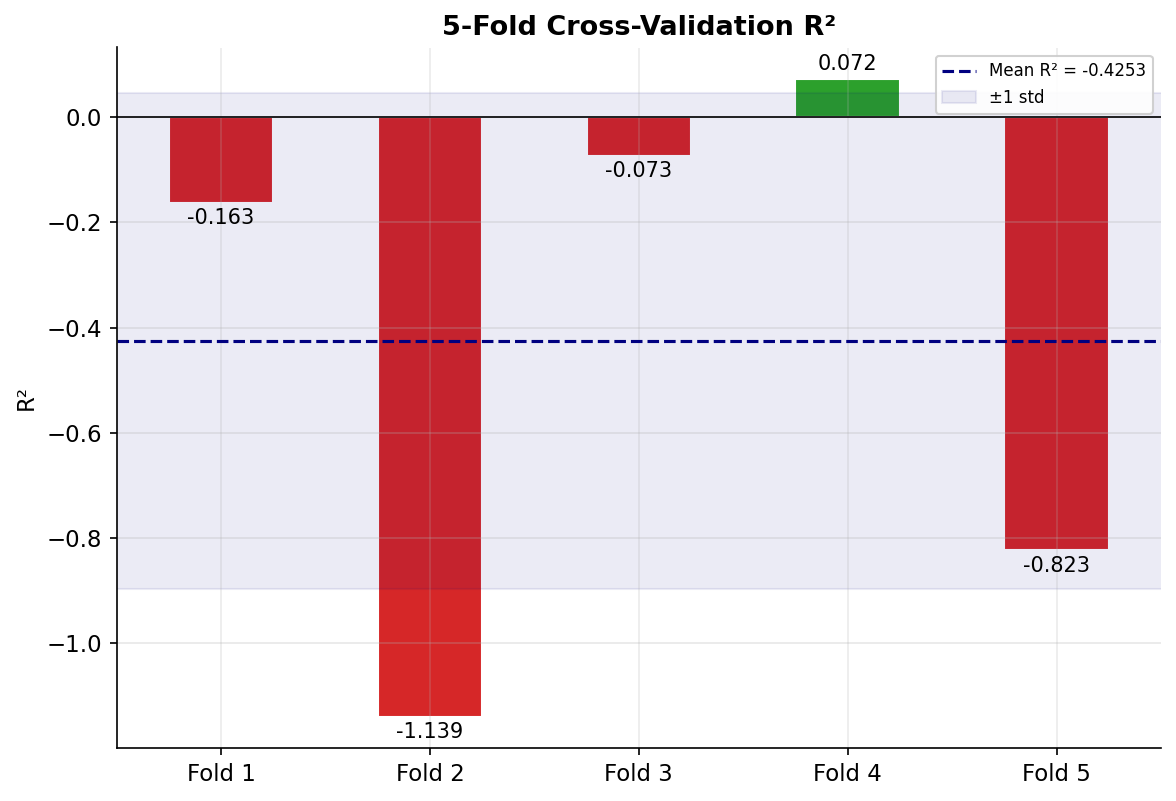

In [6]:
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2"
)

print("5-Fold Cross-Validation R² scores:")
for i, s in enumerate(cv_scores, 1):
    bar = "█" * int(max(s, 0) * 20)
    print(f"  Fold {i}: {s:+.4f}  {bar}")
print()
print(f"  Mean R²  : {cv_scores.mean():+.4f}")
print(f"  Std  R²  :  {cv_scores.std():.4f}")
print(f"  95% CI   : [{cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")

# visualise
fig, ax = plt.subplots(figsize=(8, 5.5))
fold_labels = [f"Fold {i}" for i in range(1, 6)]
bar_colors  = ["#2ca02c" if s > 0 else "#d62728" for s in cv_scores]
ax.bar(fold_labels, cv_scores, color=bar_colors, edgecolor="white", width=0.5)
ax.axhline(cv_scores.mean(), color="navy", ls="--", lw=1.5,
           label=f"Mean R² = {cv_scores.mean():.4f}")
ax.axhline(0, color="black", ls="-", lw=0.8)
ax.fill_between(range(-1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                color="navy", alpha=0.08, label="±1 std")
ax.set_ylabel("R²", fontsize=11)
ax.set_title("5-Fold Cross-Validation R²", fontsize=13, fontweight="bold")
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.set_xlim(-0.5, 4.5)
ax.grid(axis="y", alpha=0.3)

for i, s in enumerate(cv_scores):
    ax.text(i, s + 0.01 * np.sign(s), f"{s:.3f}",
            ha="center", va="bottom" if s >= 0 else "top", fontsize=10)

fig.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_rf_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

In [7]:
print("=" * 50)
print("  Phase 3 — Random Forest Results")
print("=" * 50)
print(f"  Features       : {FEATURES}")
print(f"  Target         : {TARGET}")
print(f"  Train size     : {X_train.shape[0]}")
print(f"  Test size      : {X_test.shape[0]}")
print()
print(f"  Train R²       : {r2_train:.4f}")
print(f"  Test  R²       : {r2_test:.4f}")
print(f"  Train RMSE     : {rmse_train:.4f}")
print(f"  Test  RMSE     : {rmse_test:.4f}")
print()
print(f"  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print("  Top feature    :", importances.index[-1],
      f"({importances.values[-1]:.3f})")
print("=" * 50)


  Phase 3 — Random Forest Results
  Features       : ['layers', 'vgs_min_V', 'vgs_max_V', 'n_points']
  Target         : on_off_ratio
  Train size     : 58
  Test size      : 15

  Train R²       : 0.1522
  Test  R²       : -0.0865
  Train RMSE     : 2.1156
  Test  RMSE     : 1.0630

  CV R² (5-fold) : -0.4253 ± 0.4706

  Top feature    : layers (0.877)
